In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('heart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [198]:
import pandas as pd
from IPython.display import display

data = [
    ["Age", "Age of patient (years)"],
    ["Sex", "Sex of patient (M=Male, F=Female)"],
    ["ChestPainType", "Type of chest pain (ATA, NAP, ASY, TA)"],
    ["RestingBP", "Resting blood pressure (mmHg)"],
    ["Cholesterol", "Serum cholesterol (mg/dL)"],
    ["FastingBS", "Fasting blood sugar >120 mg/dL (1=True, 0=False)"],
    ["RestingECG", "Resting ECG results (Normal, ST, LVH)"],
    ["MaxHR", "Maximum heart rate achieved"],
    ["ExerciseAngina", "Exercise-induced angina (Y/N)"],
    ["Oldpeak", "ST depression induced by exercise relative to rest"],
    ["ST_Slope", "Slope of peak exercise ST segment (Up, Flat, Down)"]
]

feature_desc_df = pd.DataFrame(data, columns=["Feature", "Description"])

# This will render it as a clean HTML table in your notebook
display(feature_desc_df)

,Feature,Description
0,Age,Age of patient (years)
1,Sex,"Sex of patient (M=Male, F=Female)"
2,ChestPainType,"Type of chest pain (ATA, NAP, ASY, TA)"
3,RestingBP,Resting blood pressure (mmHg)
4,Cholesterol,Serum cholesterol (mg/dL)
5,FastingBS,"Fasting blood sugar >120 mg/dL (1=True, 0=False)"
6,RestingECG,"Resting ECG results (Normal, ST, LVH)"
7,MaxHR,Maximum heart rate achieved
8,ExerciseAngina,Exercise-induced angina (Y/N)
9,Oldpeak,ST depression induced by exercise relative to ...


In [151]:
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [152]:
summary = pd.DataFrame({
    'missing (NaN)': df.isnull().sum(),
    'zero count': (df == 0).sum(),
})
summary

,missing (NaN),zero count
Age,0,0
Sex,0,0
ChestPainType,0,0
RestingBP,0,1
Cholesterol,0,172
FastingBS,0,704
RestingECG,0,0
MaxHR,0,0
ExerciseAngina,0,0
Oldpeak,0,368


In [153]:
df['HeartDisease'].value_counts(normalize=True) * 100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [154]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [155]:
X_train['RestingBP'].describe()

count    734.000000
mean     132.874659
std       18.080330
min       92.000000
25%      120.000000
50%      130.000000
75%      141.000000
max      200.000000
Name: RestingBP, dtype: float64

In [156]:
X_train['RestingBP'] = X_train['RestingBP'].replace(0, np.nan)
X_test['RestingBP'] = X_test['RestingBP'].replace(0, np.nan)

resting_bp_group_means = X_train.groupby(['Age', 'Sex'])['RestingBP'].mean()
overall_resting_bp_mean = X_train['RestingBP'].mean()

def fill_resting_bp(row):
    # If it's already a valid number, return it
    if pd.notna(row['RestingBP']):
        return row['RestingBP']
    
    # Try to get the mean for their specific Age and Sex
    group_mean = resting_bp_group_means.get((row['Age'], row['Sex']))
    
    # Return the group mean if it exists and isn't NaN, otherwise use the overall mean
    return group_mean if pd.notna(group_mean) else overall_resting_bp_mean
   
X_train['RestingBP'] = X_train.apply(fill_resting_bp, axis=1).round().astype(int)
X_test['RestingBP'] = X_test.apply(fill_resting_bp, axis=1).round().astype(int)

X_train['RestingBP'].describe()

count    734.000000
mean     132.874659
std       18.080330
min       92.000000
25%      120.000000
50%      130.000000
75%      141.000000
max      200.000000
Name: RestingBP, dtype: float64

In [157]:

X_train['Cholesterol'] = X_train['Cholesterol'].replace(0, np.nan)
X_test['Cholesterol'] = X_test['Cholesterol'].replace(0, np.nan)

cholesterol_group_means = X_train.groupby(['Age', 'Sex'])['Cholesterol'].mean()
overall_cholesterol_mean = X_train['Cholesterol'].mean()

def fill_cholesterol(row):
   
    if pd.notna(row['Cholesterol']):
        return row['Cholesterol']
    
    
    group_mean = cholesterol_group_means.get((row['Age'], row['Sex']))
    
    # Return the group mean if it exists and isn't NaN, otherwise use the overall mean
    return group_mean if pd.notna(group_mean) else overall_cholesterol_mean

X_train['Cholesterol'] = X_train.apply(fill_cholesterol, axis=1).round().astype(int)
X_test['Cholesterol'] = X_test.apply(fill_cholesterol, axis=1).round().astype(int)


X_train['Cholesterol'].describe()

count    734.000000
mean     245.967302
std       54.807405
min       85.000000
25%      214.000000
50%      240.000000
75%      271.000000
max      603.000000
Name: Cholesterol, dtype: float64

In [158]:

X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Train shape: {X_train_encoded.shape}")
print(f"Test shape: {X_test_encoded.shape}")

Train shape: (734, 20)
Test shape: (184, 20)


In [159]:

heart_disease_corr = X_train_encoded.corrwith(y_train).sort_values(ascending=False)

print(heart_disease_corr)

ST_Slope_Flat        0.570791
ChestPainType_ASY    0.518156
ExerciseAngina_Y     0.490873
Oldpeak              0.376603
Sex_M                0.280220
FastingBS            0.261391
Age                  0.244689
ST_Slope_Down        0.145547
RestingECG_ST        0.104397
RestingBP            0.102055
Cholesterol          0.072061
RestingECG_LVH       0.022259
ChestPainType_TA    -0.049802
RestingECG_Normal   -0.102490
ChestPainType_NAP   -0.226506
Sex_F               -0.280220
ChestPainType_ATA   -0.396565
MaxHR               -0.407227
ExerciseAngina_N    -0.490873
ST_Slope_Up         -0.649014
dtype: float64


In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import pandas as pd
from IPython.display import display

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
   
    model.fit(X_train_encoded, y_train)

    y_pred = model.predict(X_test_encoded)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": report['accuracy'],
        "Precision (Class 1)": report['1']['precision'],
        "Recall (Class 1 - Sensitivity)": report['1']['recall'],
        "F1-Score (Class 1)": report['1']['f1-score']
    })

results_df = pd.DataFrame(results).round(4)

target_metric = 'Recall (Class 1 - Sensitivity)'

results_df_sorted = results_df.sort_values(by=[target_metric, 'F1-Score (Class 1)'], ascending=[False, False])

champion_name = results_df_sorted.iloc[0]['Model']
champion_recall = results_df_sorted.iloc[0][target_metric]
champion_f1 = results_df_sorted.iloc[0]['F1-Score (Class 1)']

# ---> NEW: Save the actual trained model object into a variable <---
champion_model = models[champion_name]


display(results_df_sorted)

print("\n🏆 --- CHAMPION MODEL --- 🏆")
print(f"Model: {champion_name}")
print(f"Heart Disease Recall: {champion_recall:.4f}")
print(f"Heart Disease F1-Score: {champion_f1:.4f}")
print("-" * 30)

,Model,Accuracy,Precision (Class 1),Recall (Class 1 - Sensitivity),F1-Score (Class 1)
0,Logistic Regression,0.8913,0.8942,0.9118,0.9029
1,Random Forest,0.8750,0.8762,0.9020,0.8889
3,Gradient Boosting,0.8750,0.8911,0.8824,0.8867
2,XGBoost,0.8587,0.9043,0.8333,0.8673
4,Support Vector Machine,0.7120,0.7290,0.7647,0.7464



🏆 --- CHAMPION MODEL --- 🏆
Model: Logistic Regression
Heart Disease Recall: 0.9118
Heart Disease F1-Score: 0.9029
------------------------------


--- Logistic Regression Feature Importances ---



,Feature,Importance
19,ST_Slope_Up,1.266950
8,ChestPainType_ASY,1.196528
3,FastingBS,1.172770
18,ST_Slope_Flat,1.067592
7,Sex_M,0.700121
6,Sex_F,0.685841
10,ChestPainType_NAP,0.512308
9,ChestPainType_ATA,0.495738
16,ExerciseAngina_Y,0.416812
15,ExerciseAngina_N,0.402531


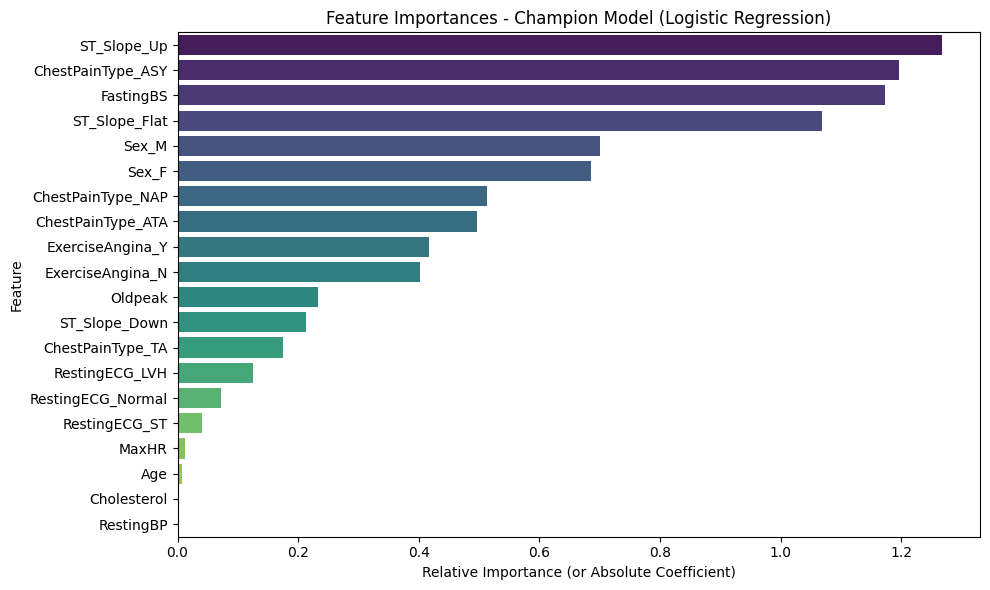

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


if hasattr(champion_model, 'feature_importances_'):
   
    importances = champion_model.feature_importances_
elif hasattr(champion_model, 'coef_'):
  
    importances = np.abs(champion_model.coef_[0])
else:
    print(f"Cannot extract feature importances for {champion_name}")
    importances = np.zeros(len(X_train_encoded.columns))

feature_names = X_train_encoded.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Print the exact values
print(f"--- {champion_name} Feature Importances ---\n")
display(feature_importance_df)

# 5. Plot a bar chart for easy visual inspection
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title(f'Feature Importances - Champion Model ({champion_name})')
plt.xlabel('Relative Importance (or Absolute Coefficient)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [162]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

base_estimator = clone(models[champion_name])
if "n_jobs" in base_estimator.get_params():
    base_estimator.set_params(n_jobs=1)  

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 6, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.8, 1.0],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.8, 1.0],
    },
    "Support Vector Machine": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
    },
}
param_grid = param_grids[champion_name]

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    cv=5,                
    scoring='recall',    
    n_jobs=-1,          
)

print(f"Starting Grid Search on {champion_name}... this might take a minute.")
grid_search.fit(X_train_encoded, y_train)

# 4. Extract the best model from the search
# NOTE: kept the name best_rf_model since later cells reference it -- it now
# holds whichever model type won champion selection, not necessarily a
# Random Forest.
best_rf_model = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found:\n{grid_search.best_params_}")

# 5. Predict and evaluate using the best model
y_pred_tuned = best_rf_model.predict(X_test_encoded)
report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True)

# 6. Print the final results
print(f"\n🏆 --- TUNED MODEL PERFORMANCE ({champion_name}) --- 🏆")
print(f"Accuracy:             {report_tuned['accuracy']:.4f}")
print(f"Heart Disease Recall: {report_tuned['1']['recall']:.4f}")
print(f"Heart Disease F1:     {report_tuned['1']['f1-score']:.4f}")

Starting Grid Search on Logistic Regression... this might take a minute.

✅ Best Parameters Found:
{'C': 0.1, 'class_weight': None}

🏆 --- TUNED MODEL PERFORMANCE (Logistic Regression) --- 🏆
Accuracy:             0.8967
Heart Disease Recall: 0.9118
Heart Disease F1:     0.9073


📊 FULL CLASSIFICATION REPORT (Tuned Logistic Regression)
                      precision    recall  f1-score   support

No Heart Disease (0)       0.89      0.88      0.88        82
   Heart Disease (1)       0.90      0.91      0.91       102

            accuracy                           0.90       184
           macro avg       0.90      0.89      0.90       184
        weighted avg       0.90      0.90      0.90       184

ROC-AUC Score: 0.9332
PR-AUC Score:  0.9413



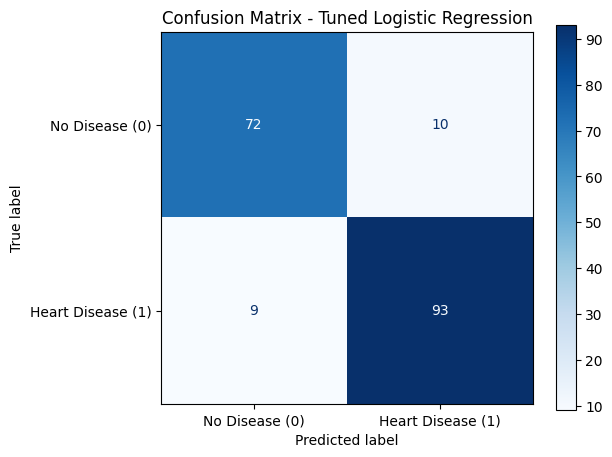

True Positives  (Correctly caught Heart Disease): 93
False Negatives (Missed Heart Disease - Critical!): 9
True Negatives  (Correctly identified Healthy):     72
False Positives (False Alarms):                     10


In [163]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# 1. Full Classification Report (Precision, Recall, F1, Support for both classes)
print("=" * 60)
print(f"📊 FULL CLASSIFICATION REPORT (Tuned {champion_name})")
print("=" * 60)
print(classification_report(y_test, y_pred_tuned, target_names=['No Heart Disease (0)', 'Heart Disease (1)']))

# 2. ROC-AUC / PR-AUC Scores
y_prob_tuned = best_rf_model.predict_proba(X_test_encoded)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_tuned)
pr_auc = average_precision_score(y_test, y_prob_tuned)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score:  {pr_auc:.4f}\n")

# 3. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Heart Disease (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f"Confusion Matrix - Tuned {champion_name}")
plt.grid(False)
plt.show()

# 4. Detailed Breakdown of Errors
tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (Correctly caught Heart Disease): {tp}")
print(f"False Negatives (Missed Heart Disease - Critical!): {fn}")
print(f"True Negatives  (Correctly identified Healthy):     {tn}")
print(f"False Positives (False Alarms):                     {fp}")

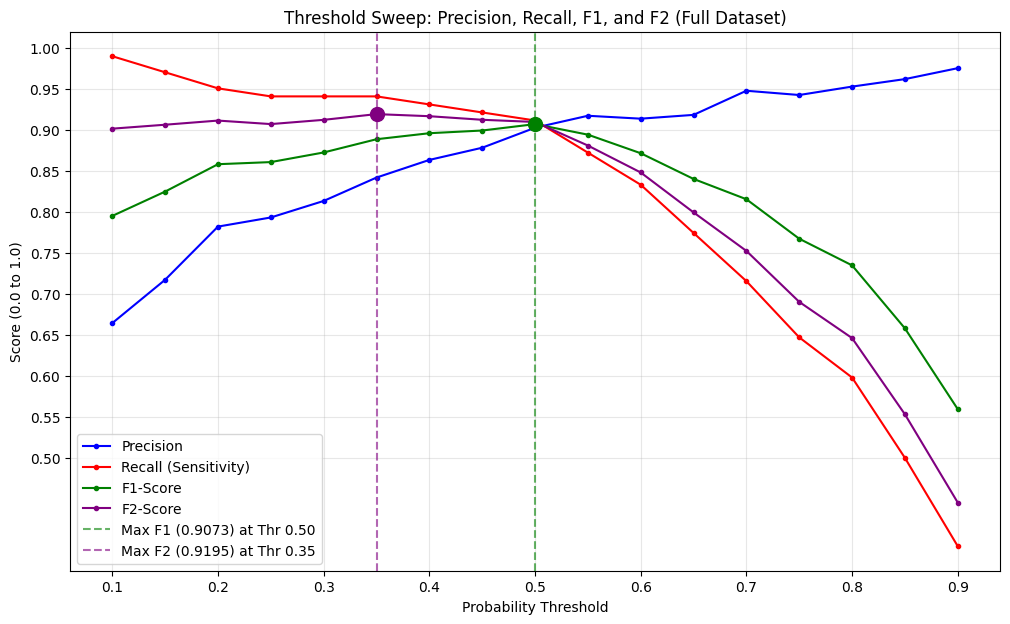

🌟 MAX F1-SCORE: 0.9073 (Occurs at Threshold: 0.50)
🌟 MAX F2-SCORE: 0.9195 (Occurs at Threshold: 0.35)



,Threshold,Precision,Recall,F1-Score,F2-Score
5,0.35,0.8421,0.9412,0.8889,0.9195
6,0.40,0.8636,0.9314,0.8962,0.9170
7,0.45,0.8785,0.9216,0.8995,0.9126
4,0.30,0.8136,0.9412,0.8727,0.9125
2,0.20,0.7823,0.9510,0.8584,0.9117
8,0.50,0.9029,0.9118,0.9073,0.9100
3,0.25,0.7934,0.9412,0.8610,0.9074
1,0.15,0.7174,0.9706,0.8250,0.9066
0,0.10,0.6645,0.9902,0.7953,0.9018
9,0.55,0.9175,0.8725,0.8945,0.8812


In [164]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

y_prob_tuned = best_rf_model.predict_proba(X_test_encoded)[:, 1]


thresholds = np.arange(0.1, 0.95, 0.05)
metrics = []


for t in thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    
    # FIXED: Using full dataset y_test
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    f2 = fbeta_score(y_test, y_pred_t, beta=2) # F2 calculation
    
    metrics.append({
        'Threshold': t,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'F2-Score': f2
    })

# 4. Convert to DataFrame
metrics_df = pd.DataFrame(metrics)

# --- Find the Rows with the Max F1 and Max F2 ---
best_f1_row = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
best_f2_row = metrics_df.loc[metrics_df['F2-Score'].idxmax()]

# 5. Plot the trade-off curves
plt.figure(figsize=(12, 7))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], label='Precision', marker='.', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], label='Recall (Sensitivity)', marker='.', color='red')
plt.plot(metrics_df['Threshold'], metrics_df['F1-Score'], label='F1-Score', marker='.', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F2-Score'], label='F2-Score', marker='.', color='purple')

# Highlight Max F1
plt.axvline(x=best_f1_row['Threshold'], color='green', linestyle='--', alpha=0.6, 
            label=f"Max F1 ({best_f1_row['F1-Score']:.4f}) at Thr {best_f1_row['Threshold']:.2f}")
plt.scatter(best_f1_row['Threshold'], best_f1_row['F1-Score'], color='green', s=100, zorder=5)

# Highlight Max F2
plt.axvline(x=best_f2_row['Threshold'], color='purple', linestyle='--', alpha=0.6, 
            label=f"Max F2 ({best_f2_row['F2-Score']:.4f}) at Thr {best_f2_row['Threshold']:.2f}")
plt.scatter(best_f2_row['Threshold'], best_f2_row['F2-Score'], color='purple', s=100, zorder=5)

# Formatting the plot
plt.title('Threshold Sweep: Precision, Recall, F1, and F2 (Full Dataset)')
plt.xlabel('Probability Threshold')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.yticks(np.arange(0.5, 1.05, 0.05))
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Print maxes and display the sorted table
print(f"🌟 MAX F1-SCORE: {best_f1_row['F1-Score']:.4f} (Occurs at Threshold: {best_f1_row['Threshold']:.2f})")
print(f"🌟 MAX F2-SCORE: {best_f2_row['F2-Score']:.4f} (Occurs at Threshold: {best_f2_row['Threshold']:.2f})\n")

display(metrics_df.sort_values(by=['F2-Score', 'Recall'], ascending=[False, False]).round(4))


--- F1-Max (threshold=0.50) ---
True Positives  (Correctly caught Heart Disease):   93
False Negatives (Missed Heart Disease - Critical!): 9
True Negatives  (Correctly identified Healthy):     72
False Positives (False Alarms):                     10

--- F2-Max (threshold=0.35) ---
True Positives  (Correctly caught Heart Disease):   96
False Negatives (Missed Heart Disease - Critical!): 6
True Negatives  (Correctly identified Healthy):     64
False Positives (False Alarms):                     18


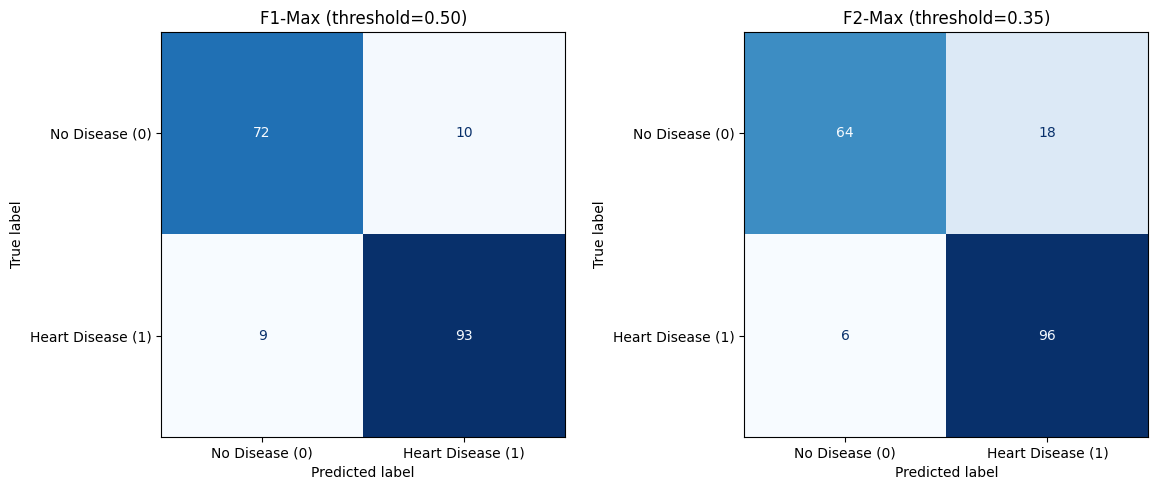

In [165]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def print_and_plot_confusion(threshold, label, ax):
    y_pred_at_threshold = (y_prob_tuned >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_at_threshold)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n--- {label} (threshold={threshold:.2f}) ---")
    print(f"True Positives  (Correctly caught Heart Disease):   {tp}")
    print(f"False Negatives (Missed Heart Disease - Critical!): {fn}")
    print(f"True Negatives  (Correctly identified Healthy):     {tn}")
    print(f"False Positives (False Alarms):                     {fp}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Heart Disease (1)'])
    disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
    ax.set_title(f"{label} (threshold={threshold:.2f})")
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
print_and_plot_confusion(best_f1_row['Threshold'], 'F1-Max', axes[0])
print_and_plot_confusion(best_f2_row['Threshold'], 'F2-Max', axes[1])
plt.tight_layout()
plt.show()

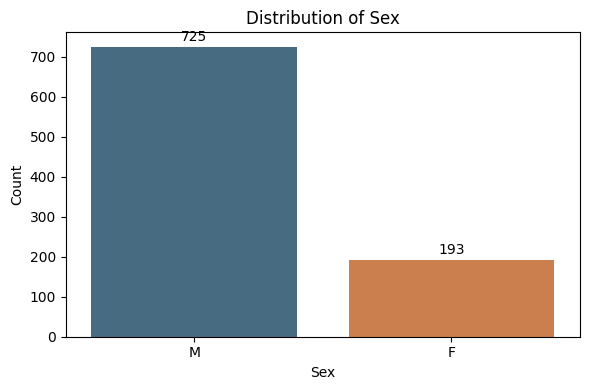

Saved to sex_distribution.png


In [166]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Sex', palette=['#3d6e8c', '#e07b39'])

plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

# Add the exact count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.tight_layout()
plt.savefig('sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to sex_distribution.png")

In [167]:
male_train_mask = X_train_encoded['Sex_M'] == 1
male_test_mask = X_test_encoded['Sex_M'] == 1

X_train_male = X_train_encoded[male_train_mask]
y_train_male = y_train[male_train_mask]
X_test_male = X_test_encoded[male_test_mask]
y_test_male = y_test[male_test_mask]

X_train_female = X_train_encoded[~male_train_mask]
y_train_female = y_train[~male_train_mask]
X_test_female = X_test_encoded[~male_test_mask]
y_test_female = y_test[~male_test_mask]

print(f"Male   -- train: {X_train_male.shape[0]}, test: {X_test_male.shape[0]}")
print(f"Female -- train: {X_train_female.shape[0]}, test: {X_test_female.shape[0]}")

Male   -- train: 579, test: 146
Female -- train: 155, test: 38


In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import pandas as pd
from IPython.display import display

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
   
    model.fit(X_train_male, y_train_male)

    y_pred_male = model.predict(X_test_male)

    report = classification_report(y_test_male, y_pred_male, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": report['accuracy'],
        "Precision (Class 1)": report['1']['precision'],
        "Recall (Class 1 - Sensitivity)": report['1']['recall'],
        "F1-Score (Class 1)": report['1']['f1-score']
    })

results_df = pd.DataFrame(results).round(4)

target_metric = 'Recall (Class 1 - Sensitivity)'

results_df_sorted = results_df.sort_values(by=[target_metric, 'F1-Score (Class 1)'], ascending=[False, False])

champion_name = results_df_sorted.iloc[0]['Model']
champion_recall = results_df_sorted.iloc[0][target_metric]
champion_f1 = results_df_sorted.iloc[0]['F1-Score (Class 1)']

# ---> NEW: Save the actual trained model object into a variable <---
champion_model = models[champion_name]


display(results_df_sorted)

print("\n🏆 --- CHAMPION MODEL --- 🏆")
print(f"Model: {champion_name}")
print(f"Heart Disease Recall: {champion_recall:.4f}")
print(f"Heart Disease F1-Score: {champion_f1:.4f}")
print("-" * 30)

,Model,Accuracy,Precision (Class 1),Recall (Class 1 - Sensitivity),F1-Score (Class 1)
0,Logistic Regression,0.8767,0.8980,0.9167,0.9072
1,Random Forest,0.8562,0.8713,0.9167,0.8934
2,XGBoost,0.8562,0.8947,0.8854,0.8901
3,Gradient Boosting,0.8425,0.8925,0.8646,0.8783
4,Support Vector Machine,0.7123,0.7411,0.8646,0.7981



🏆 --- CHAMPION MODEL --- 🏆
Model: Logistic Regression
Heart Disease Recall: 0.9167
Heart Disease F1-Score: 0.9072
------------------------------


In [169]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
import warnings

# Suppress both FutureWarnings and ConvergenceWarnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

base_estimator = clone(models[champion_name])
if "n_jobs" in base_estimator.get_params():
    base_estimator.set_params(n_jobs=1)  

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 6, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.8, 1.0],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.8, 1.0],
    },
    "Support Vector Machine": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
    },
}
param_grid = param_grids[champion_name]

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    cv=5,                
    scoring='recall',    
    n_jobs=-1,          
)

print(f"Starting Grid Search on {champion_name}... this might take a minute.")
grid_search.fit(X_train_male, y_train_male)

# ---> FIXED: Renamed 'best_rf_model' to 'best_male_model' <---
best_male_model = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found:\n{grid_search.best_params_}")

# Predict using the newly named best_male_model
y_pred_tuned_male = best_male_model.predict(X_test_male)
report_tuned_male = classification_report(y_test_male, y_pred_tuned_male, output_dict=True)

print(f"\n🏆 --- TUNED MODEL PERFORMANCE ({champion_name}) --- 🏆")
print(f"Accuracy:             {report_tuned_male['accuracy']:.4f}")
print(f"Heart Disease Recall: {report_tuned_male['1']['recall']:.4f}")
print(f"Heart Disease F1:     {report_tuned_male['1']['f1-score']:.4f}")

Starting Grid Search on Logistic Regression... this might take a minute.

✅ Best Parameters Found:
{'C': 0.1, 'class_weight': None}

🏆 --- TUNED MODEL PERFORMANCE (Logistic Regression) --- 🏆
Accuracy:             0.8973
Heart Disease Recall: 0.9271
Heart Disease F1:     0.9223


📊 FULL CLASSIFICATION REPORT (Tuned Logistic Regression) - MALE DATASET
                      precision    recall  f1-score   support

No Heart Disease (0)       0.86      0.84      0.85        50
   Heart Disease (1)       0.92      0.93      0.92        96

            accuracy                           0.90       146
           macro avg       0.89      0.88      0.89       146
        weighted avg       0.90      0.90      0.90       146

ROC-AUC Score: 0.9138
PR-AUC Score:  0.9452



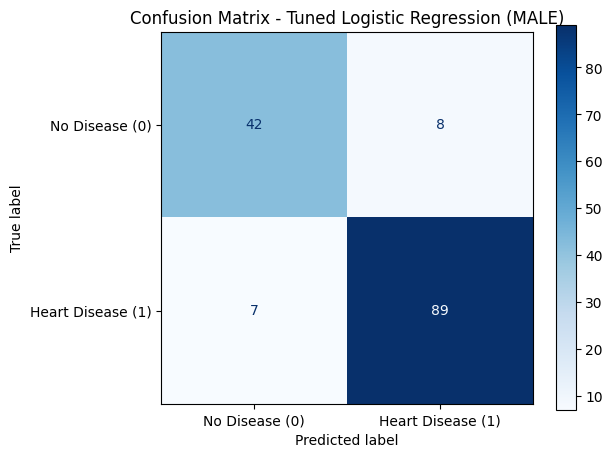

True Positives  (Correctly caught Heart Disease): 89
False Negatives (Missed Heart Disease - Critical!): 7
True Negatives  (Correctly identified Healthy):     42
False Positives (False Alarms):                     8


In [170]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

print("=" * 60)
print(f"📊 FULL CLASSIFICATION REPORT (Tuned {champion_name}) - MALE DATASET")
print("=" * 60)
print(classification_report(y_test_male, y_pred_tuned_male, target_names=['No Heart Disease (0)', 'Heart Disease (1)']))

# 2. ROC-AUC / PR-AUC Scores
y_prob_tuned_male = best_male_model.predict_proba(X_test_male)[:, 1]
roc_auc_male = roc_auc_score(y_test_male, y_prob_tuned_male)
pr_auc_male = average_precision_score(y_test_male, y_prob_tuned_male)
print(f"ROC-AUC Score: {roc_auc_male:.4f}")
print(f"PR-AUC Score:  {pr_auc_male:.4f}\n")

# 3. Confusion Matrix Plot
cm_male = confusion_matrix(y_test_male, y_pred_tuned_male)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_male, display_labels=['No Disease (0)', 'Heart Disease (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f"Confusion Matrix - Tuned {champion_name} (MALE)")
plt.grid(False)
plt.show()

# 4. Detailed Breakdown of Errors
tn, fp, fn, tp = cm_male.ravel()
print(f"True Positives  (Correctly caught Heart Disease): {tp}")
print(f"False Negatives (Missed Heart Disease - Critical!): {fn}")
print(f"True Negatives  (Correctly identified Healthy):     {tn}")
print(f"False Positives (False Alarms):                     {fp}")

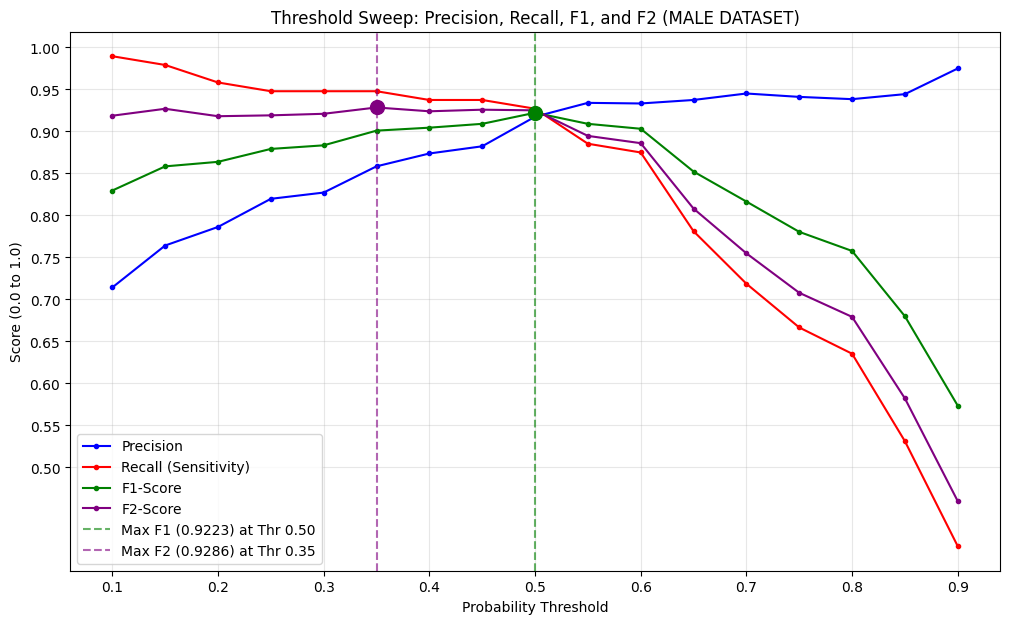

🌟 MAX F1-SCORE (MALE): 0.9223 (Occurs at Threshold: 0.50)
🌟 MAX F2-SCORE (MALE): 0.9286 (Occurs at Threshold: 0.35)



,Threshold,Precision,Recall,F1-Score,F2-Score
5,0.35,0.8585,0.9479,0.9010,0.9286
1,0.15,0.7642,0.9792,0.8584,0.9270
7,0.45,0.8824,0.9375,0.9091,0.9259
8,0.50,0.9175,0.9271,0.9223,0.9252
6,0.40,0.8738,0.9375,0.9045,0.9240
4,0.30,0.8273,0.9479,0.8835,0.9211
3,0.25,0.8198,0.9479,0.8792,0.9192
0,0.10,0.7143,0.9896,0.8297,0.9188
2,0.20,0.7863,0.9583,0.8638,0.9182
9,0.55,0.9341,0.8854,0.9091,0.8947


In [171]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

y_prob_tuned_male = best_male_model.predict_proba(X_test_male)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
metrics_male = []

for t in thresholds:
    y_pred_t = (y_prob_tuned_male >= t).astype(int)
    
    # FIXED: Using male dataset y_test
    precision = precision_score(y_test_male, y_pred_t, zero_division=0)
    recall = recall_score(y_test_male, y_pred_t)
    f1 = f1_score(y_test_male, y_pred_t)
    f2 = fbeta_score(y_test_male, y_pred_t, beta=2) # F2 calculation
    
    metrics_male.append({
        'Threshold': t,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'F2-Score': f2
    })

# 4. Convert to DataFrame
metrics_df_male = pd.DataFrame(metrics_male)

# --- Find the Rows with the Max F1 and Max F2 ---
best_f1_row_male = metrics_df_male.loc[metrics_df_male['F1-Score'].idxmax()]
best_f2_row_male = metrics_df_male.loc[metrics_df_male['F2-Score'].idxmax()]

# 5. Plot the trade-off curves
plt.figure(figsize=(12, 7))
plt.plot(metrics_df_male['Threshold'], metrics_df_male['Precision'], label='Precision', marker='.', color='blue')
plt.plot(metrics_df_male['Threshold'], metrics_df_male['Recall'], label='Recall (Sensitivity)', marker='.', color='red')
plt.plot(metrics_df_male['Threshold'], metrics_df_male['F1-Score'], label='F1-Score', marker='.', color='green')
plt.plot(metrics_df_male['Threshold'], metrics_df_male['F2-Score'], label='F2-Score', marker='.', color='purple')

# Highlight Max F1
plt.axvline(x=best_f1_row_male['Threshold'], color='green', linestyle='--', alpha=0.6, 
            label=f"Max F1 ({best_f1_row_male['F1-Score']:.4f}) at Thr {best_f1_row_male['Threshold']:.2f}")
plt.scatter(best_f1_row_male['Threshold'], best_f1_row_male['F1-Score'], color='green', s=100, zorder=5)

# Highlight Max F2
plt.axvline(x=best_f2_row_male['Threshold'], color='purple', linestyle='--', alpha=0.6, 
            label=f"Max F2 ({best_f2_row_male['F2-Score']:.4f}) at Thr {best_f2_row_male['Threshold']:.2f}")
plt.scatter(best_f2_row_male['Threshold'], best_f2_row_male['F2-Score'], color='purple', s=100, zorder=5)

# Formatting the plot
plt.title('Threshold Sweep: Precision, Recall, F1, and F2 (MALE DATASET)')
plt.xlabel('Probability Threshold')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.yticks(np.arange(0.5, 1.05, 0.05))
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Print maxes and display the sorted table
print(f"🌟 MAX F1-SCORE (MALE): {best_f1_row_male['F1-Score']:.4f} (Occurs at Threshold: {best_f1_row_male['Threshold']:.2f})")
print(f"🌟 MAX F2-SCORE (MALE): {best_f2_row_male['F2-Score']:.4f} (Occurs at Threshold: {best_f2_row_male['Threshold']:.2f})\n")

display(metrics_df_male.sort_values(by=['F2-Score', 'Recall'], ascending=[False, False]).round(4))


--- F1-Max (threshold=0.50) - MALE DATASET ---
True Positives  (Correctly caught Heart Disease):   89
False Negatives (Missed Heart Disease - Critical!): 7
True Negatives  (Correctly identified Healthy):     42
False Positives (False Alarms):                     8

--- F2-Max (threshold=0.35) - MALE DATASET ---
True Positives  (Correctly caught Heart Disease):   91
False Negatives (Missed Heart Disease - Critical!): 5
True Negatives  (Correctly identified Healthy):     35
False Positives (False Alarms):                     15


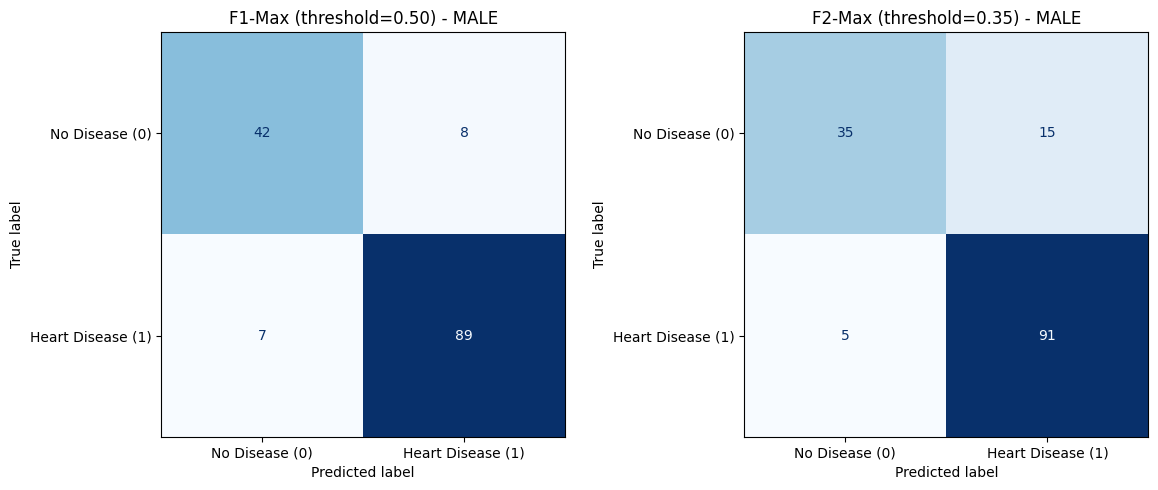

In [172]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def print_and_plot_confusion_male(threshold, label, ax):
    y_pred_at_threshold = (y_prob_tuned_male >= threshold).astype(int)
    cm = confusion_matrix(y_test_male, y_pred_at_threshold)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n--- {label} (threshold={threshold:.2f}) - MALE DATASET ---")
    print(f"True Positives  (Correctly caught Heart Disease):   {tp}")
    print(f"False Negatives (Missed Heart Disease - Critical!): {fn}")
    print(f"True Negatives  (Correctly identified Healthy):     {tn}")
    print(f"False Positives (False Alarms):                     {fp}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Heart Disease (1)'])
    disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
    ax.set_title(f"{label} (threshold={threshold:.2f}) - MALE")
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
print_and_plot_confusion_male(best_f1_row_male['Threshold'], 'F1-Max', axes[0])
print_and_plot_confusion_male(best_f2_row_male['Threshold'], 'F2-Max', axes[1])
plt.tight_layout()
plt.show()

In [173]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
   
    model.fit(X_train_female, y_train_female)

    y_pred_female = model.predict(X_test_female)

    report = classification_report(y_test_female, y_pred_female, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": report['accuracy'],
        "Precision (Class 1)": report['1']['precision'],
        "Recall (Class 1 - Sensitivity)": report['1']['recall'],
        "F1-Score (Class 1)": report['1']['f1-score']
    })

results_df = pd.DataFrame(results).round(4)

target_metric = 'Recall (Class 1 - Sensitivity)'

results_df_sorted = results_df.sort_values(by=[target_metric, 'F1-Score (Class 1)'], ascending=[False, False])

champion_name = results_df_sorted.iloc[0]['Model']
champion_recall = results_df_sorted.iloc[0][target_metric]
champion_f1 = results_df_sorted.iloc[0]['F1-Score (Class 1)']

# ---> NEW: Save the actual trained model object into a variable <---
champion_model = models[champion_name]


display(results_df_sorted)

print("\n🏆 --- CHAMPION MODEL --- 🏆")
print(f"Model: {champion_name}")
print(f"Heart Disease Recall: {champion_recall:.4f}")
print(f"Heart Disease F1-Score: {champion_f1:.4f}")
print("-" * 30)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

,Model,Accuracy,Precision (Class 1),Recall (Class 1 - Sensitivity),F1-Score (Class 1)
0,Logistic Regression,0.9211,0.8000,0.6667,0.7273
1,Random Forest,0.9211,1.0000,0.5000,0.6667
2,XGBoost,0.8947,1.0000,0.3333,0.5000
3,Gradient Boosting,0.8684,0.6667,0.3333,0.4444
4,Support Vector Machine,0.8421,0.0000,0.0000,0.0000



🏆 --- CHAMPION MODEL --- 🏆
Model: Logistic Regression
Heart Disease Recall: 0.6667
Heart Disease F1-Score: 0.7273
------------------------------


In [174]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

base_estimator = clone(models[champion_name])
if "n_jobs" in base_estimator.get_params():
    base_estimator.set_params(n_jobs=1)  

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 6, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.8, 1.0],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.8, 1.0],
    },
    "Support Vector Machine": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
    },
}
param_grid = param_grids[champion_name]

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    cv=5,                
    scoring='recall',    
    n_jobs=-1,          
)

print(f"Starting Grid Search on {champion_name}... this might take a minute.")
grid_search.fit(X_train_female, y_train_female)


best_female_model = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found:\n{grid_search.best_params_}")

y_pred_tuned_female = best_rf_model.predict(X_test_female)
report_tuned_female = classification_report(y_test_female, y_pred_tuned_female, output_dict=True)

print(f"\n🏆 --- TUNED MODEL PERFORMANCE ({champion_name}) --- 🏆")
print(f"Accuracy:             {report_tuned_female['accuracy']:.4f}")
print(f"Heart Disease Recall: {report_tuned_female['1']['recall']:.4f}")
print(f"Heart Disease F1:     {report_tuned_female['1']['f1-score']:.4f}")

Starting Grid Search on Logistic Regression... this might take a minute.

✅ Best Parameters Found:
{'C': 0.1, 'class_weight': 'balanced'}

🏆 --- TUNED MODEL PERFORMANCE (Logistic Regression) --- 🏆
Accuracy:             0.8684
Heart Disease Recall: 0.6667
Heart Disease F1:     0.6154


📊 FULL CLASSIFICATION REPORT (Tuned Logistic Regression) - FEMALE DATASET
                      precision    recall  f1-score   support

No Heart Disease (0)       0.94      0.91      0.92        32
   Heart Disease (1)       0.57      0.67      0.62         6

            accuracy                           0.87        38
           macro avg       0.75      0.79      0.77        38
        weighted avg       0.88      0.87      0.87        38

ROC-AUC Score: 0.9427
PR-AUC Score:  0.8093



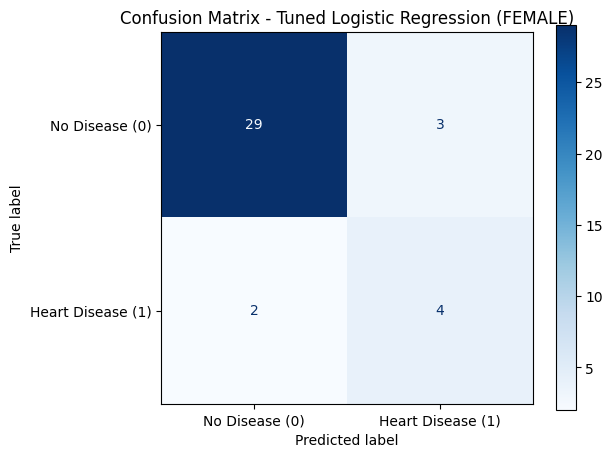

True Positives  (Correctly caught Heart Disease): 4
False Negatives (Missed Heart Disease - Critical!): 2
True Negatives  (Correctly identified Healthy):     29
False Positives (False Alarms):                     3


In [175]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

print("=" * 60)
print(f"📊 FULL CLASSIFICATION REPORT (Tuned {champion_name}) - FEMALE DATASET")
print("=" * 60)
print(classification_report(y_test_female, y_pred_tuned_female, target_names=['No Heart Disease (0)', 'Heart Disease (1)']))

# 2. ROC-AUC / PR-AUC Scores
y_prob_tuned_female = best_female_model.predict_proba(X_test_female)[:, 1]
roc_auc_female = roc_auc_score(y_test_female, y_prob_tuned_female)
pr_auc_female = average_precision_score(y_test_female, y_prob_tuned_female)
print(f"ROC-AUC Score: {roc_auc_female:.4f}")
print(f"PR-AUC Score:  {pr_auc_female:.4f}\n")

# 3. Confusion Matrix Plot
cm_female = confusion_matrix(y_test_female, y_pred_tuned_female)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_female, display_labels=['No Disease (0)', 'Heart Disease (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f"Confusion Matrix - Tuned {champion_name} (FEMALE)")
plt.grid(False)
plt.show()

# 4. Detailed Breakdown of Errors
tn, fp, fn, tp = cm_female.ravel()
print(f"True Positives  (Correctly caught Heart Disease): {tp}")
print(f"False Negatives (Missed Heart Disease - Critical!): {fn}")
print(f"True Negatives  (Correctly identified Healthy):     {tn}")
print(f"False Positives (False Alarms):                     {fp}")

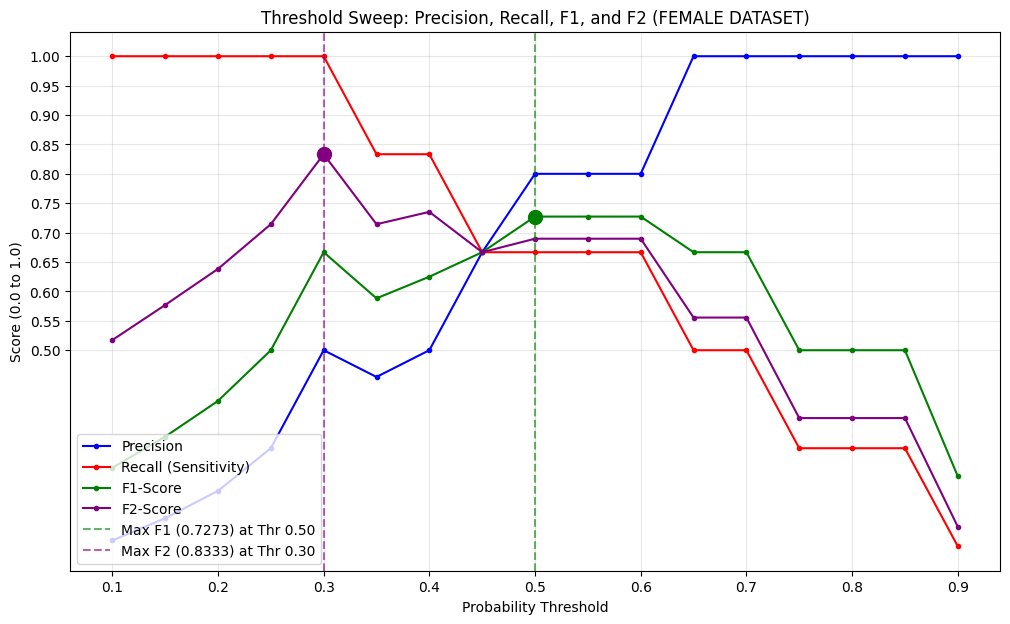

🌟 MAX F1-SCORE (FEMALE): 0.7273 (Occurs at Threshold: 0.50)
🌟 MAX F2-SCORE (FEMALE): 0.8333 (Occurs at Threshold: 0.30)



,Threshold,Precision,Recall,F1-Score,F2-Score
4,0.30,0.5000,1.0000,0.6667,0.8333
6,0.40,0.5000,0.8333,0.6250,0.7353
3,0.25,0.3333,1.0000,0.5000,0.7143
5,0.35,0.4545,0.8333,0.5882,0.7143
8,0.50,0.8000,0.6667,0.7273,0.6897
9,0.55,0.8000,0.6667,0.7273,0.6897
10,0.60,0.8000,0.6667,0.7273,0.6897
7,0.45,0.6667,0.6667,0.6667,0.6667
2,0.20,0.2609,1.0000,0.4138,0.6383
1,0.15,0.2143,1.0000,0.3529,0.5769


In [176]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

y_prob_tuned_female = best_female_model.predict_proba(X_test_female)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
metrics_female = []

for t in thresholds:
    y_pred_t = (y_prob_tuned_female >= t).astype(int)
    
    # FIXED: Using female dataset y_test
    precision = precision_score(y_test_female, y_pred_t, zero_division=0)
    recall = recall_score(y_test_female, y_pred_t)
    f1 = f1_score(y_test_female, y_pred_t)
    f2 = fbeta_score(y_test_female, y_pred_t, beta=2) # F2 calculation
    
    metrics_female.append({
        'Threshold': t,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'F2-Score': f2
    })

# 4. Convert to DataFrame
metrics_df_female = pd.DataFrame(metrics_female)

# --- Find the Rows with the Max F1 and Max F2 ---
best_f1_row_female = metrics_df_female.loc[metrics_df_female['F1-Score'].idxmax()]
best_f2_row_female = metrics_df_female.loc[metrics_df_female['F2-Score'].idxmax()]

# 5. Plot the trade-off curves
plt.figure(figsize=(12, 7))
plt.plot(metrics_df_female['Threshold'], metrics_df_female['Precision'], label='Precision', marker='.', color='blue')
plt.plot(metrics_df_female['Threshold'], metrics_df_female['Recall'], label='Recall (Sensitivity)', marker='.', color='red')
plt.plot(metrics_df_female['Threshold'], metrics_df_female['F1-Score'], label='F1-Score', marker='.', color='green')
plt.plot(metrics_df_female['Threshold'], metrics_df_female['F2-Score'], label='F2-Score', marker='.', color='purple')

# Highlight Max F1
plt.axvline(x=best_f1_row_female['Threshold'], color='green', linestyle='--', alpha=0.6, 
            label=f"Max F1 ({best_f1_row_female['F1-Score']:.4f}) at Thr {best_f1_row_female['Threshold']:.2f}")
plt.scatter(best_f1_row_female['Threshold'], best_f1_row_female['F1-Score'], color='green', s=100, zorder=5)

# Highlight Max F2
plt.axvline(x=best_f2_row_female['Threshold'], color='purple', linestyle='--', alpha=0.6, 
            label=f"Max F2 ({best_f2_row_female['F2-Score']:.4f}) at Thr {best_f2_row_female['Threshold']:.2f}")
plt.scatter(best_f2_row_female['Threshold'], best_f2_row_female['F2-Score'], color='purple', s=100, zorder=5)

# Formatting the plot
plt.title('Threshold Sweep: Precision, Recall, F1, and F2 (FEMALE DATASET)')
plt.xlabel('Probability Threshold')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.yticks(np.arange(0.5, 1.05, 0.05))
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Print maxes and display the sorted table
print(f"🌟 MAX F1-SCORE (FEMALE): {best_f1_row_female['F1-Score']:.4f} (Occurs at Threshold: {best_f1_row_female['Threshold']:.2f})")
print(f"🌟 MAX F2-SCORE (FEMALE): {best_f2_row_female['F2-Score']:.4f} (Occurs at Threshold: {best_f2_row_female['Threshold']:.2f})\n")

display(metrics_df_female.sort_values(by=['F2-Score', 'Recall'], ascending=[False, False]).round(4))


--- F1-Max (threshold=0.50) - FEMALE DATASET ---
True Positives  (Correctly caught Heart Disease):   4
False Negatives (Missed Heart Disease - Critical!): 2
True Negatives  (Correctly identified Healthy):     31
False Positives (False Alarms):                     1

--- F2-Max (threshold=0.30) - FEMALE DATASET ---
True Positives  (Correctly caught Heart Disease):   6
False Negatives (Missed Heart Disease - Critical!): 0
True Negatives  (Correctly identified Healthy):     26
False Positives (False Alarms):                     6


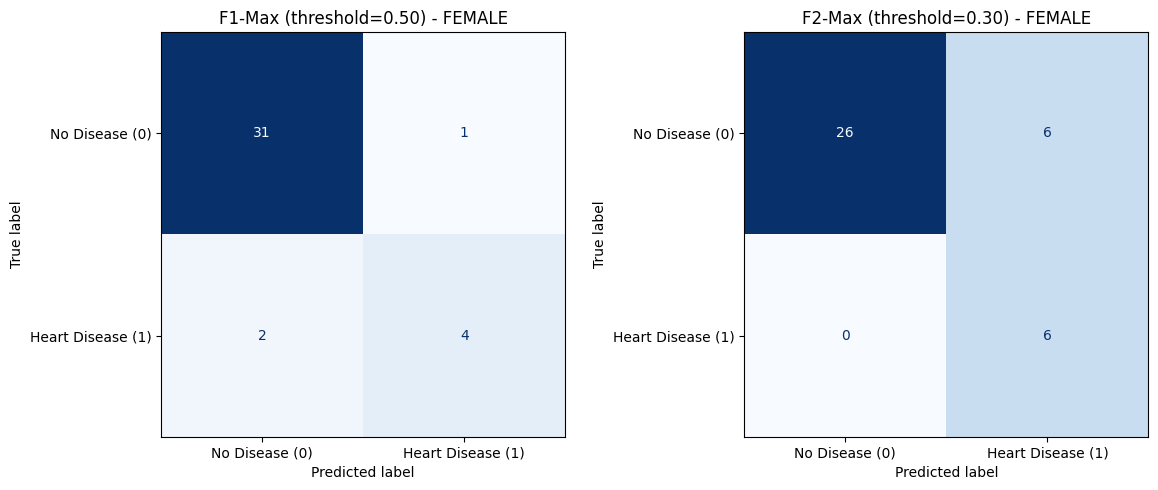

In [177]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def print_and_plot_confusion_female(threshold, label, ax):
    y_pred_at_threshold = (y_prob_tuned_female >= threshold).astype(int)
    cm = confusion_matrix(y_test_female, y_pred_at_threshold)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n--- {label} (threshold={threshold:.2f}) - FEMALE DATASET ---")
    print(f"True Positives  (Correctly caught Heart Disease):   {tp}")
    print(f"False Negatives (Missed Heart Disease - Critical!): {fn}")
    print(f"True Negatives  (Correctly identified Healthy):     {tn}")
    print(f"False Positives (False Alarms):                     {fp}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Heart Disease (1)'])
    disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
    ax.set_title(f"{label} (threshold={threshold:.2f}) - FEMALE")
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
print_and_plot_confusion_female(best_f1_row_female['Threshold'], 'F1-Max', axes[0])
print_and_plot_confusion_female(best_f2_row_female['Threshold'], 'F2-Max', axes[1])
plt.tight_layout()
plt.show()

In [178]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.base import clone
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# UPDATED: Added models that work well on small datasets
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Ridge Logistic (L2)": LogisticRegression(max_iter=1000, penalty='l2', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
}

results = []

for name, model in models.items():
    try:
        model.fit(X_train_female, y_train_female)
        y_pred_female = model.predict(X_test_female)
        report = classification_report(y_test_female, y_pred_female, output_dict=True, zero_division=0)

        results.append({
            "Model": name,
            "Accuracy": report['accuracy'],
            "Precision (Class 1)": report['1']['precision'],
            "Recall (Class 1 - Sensitivity)": report['1']['recall'],
            "F1-Score (Class 1)": report['1']['f1-score']
        })
    except Exception as e:
        print(f"⚠️ {name} failed: {str(e)}")

results_df = pd.DataFrame(results).round(4)
target_metric = 'Recall (Class 1 - Sensitivity)'
results_df_sorted = results_df.sort_values(by=[target_metric, 'F1-Score (Class 1)'], ascending=[False, False])

champion_name = results_df_sorted.iloc[0]['Model']
champion_recall = results_df_sorted.iloc[0][target_metric]
champion_f1 = results_df_sorted.iloc[0]['F1-Score (Class 1)']

champion_model = models[champion_name]

display(results_df_sorted)

print("\n🏆 --- CHAMPION MODEL (FEMALE - SMALL DATASET) --- 🏆")
print(f"Model: {champion_name}")
print(f"Heart Disease Recall: {champion_recall:.4f}")
print(f"Heart Disease F1-Score: {champion_f1:.4f}")
print("-" * 30)

# Grid search on the champion model
param_grids = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10, 100], "class_weight": [None, "balanced"]},
    "Ridge Logistic (L2)": {"C": [0.01, 0.1, 1, 10, 100], "class_weight": [None, "balanced"]},
    "Random Forest": {"n_estimators": [50, 100], "max_depth": [3, 5, 7], "min_samples_split": [5, 10]},
    "XGBoost": {"n_estimators": [50, 100], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1, 0.2]},
    "Gradient Boosting": {"n_estimators": [50, 100], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1, 0.2]},
    "Naive Bayes": {},  # No hyperparameters to tune
    "KNN (k=5)": {"n_neighbors": [3, 5, 7, 9]},
    "Decision Tree": {"max_depth": [3, 5, 7, 10], "min_samples_split": [2, 5, 10]},
}

param_grid = param_grids.get(champion_name, {})

if param_grid:  # Only do grid search if there are parameters to tune
    base_estimator = clone(models[champion_name])
    if "n_jobs" in base_estimator.get_params():
        base_estimator.set_params(n_jobs=1)

    grid_search = GridSearchCV(
        estimator=base_estimator,
        param_grid=param_grid,
        cv=5,
        scoring='recall',
        n_jobs=-1,
    )

    print(f"\n🔍 Starting Grid Search on {champion_name}... (small dataset, quick)")
    grid_search.fit(X_train_female, y_train_female)

    best_female_model = grid_search.best_estimator_
    print(f"\n✅ Best Parameters Found:\n{grid_search.best_params_}")

    y_pred_tuned_female = best_female_model.predict(X_test_female)
    report_tuned_female = classification_report(y_test_female, y_pred_tuned_female, output_dict=True, zero_division=0)

    print(f"\n🏆 --- TUNED MODEL PERFORMANCE ({champion_name}) --- 🏆")
    print(f"Accuracy:             {report_tuned_female['accuracy']:.4f}")
    print(f"Heart Disease Recall: {report_tuned_female['1']['recall']:.4f}")
    print(f"Heart Disease F1:     {report_tuned_female['1']['f1-score']:.4f}")
else:
    # For Naive Bayes (no hyperparameters)
    best_female_model = models[champion_name]
    y_pred_tuned_female = best_female_model.predict(X_test_female)
    report_tuned_female = classification_report(y_test_female, y_pred_tuned_female, output_dict=True, zero_division=0)
    
    print(f"\n🏆 --- {champion_name} (NO TUNING NEEDED) --- 🏆")
    print(f"Accuracy:             {report_tuned_female['accuracy']:.4f}")
    print(f"Heart Disease Recall: {report_tuned_female['1']['recall']:.4f}")
    print(f"Heart Disease F1:     {report_tuned_female['1']['f1-score']:.4f}")

,Model,Accuracy,Precision (Class 1),Recall (Class 1 - Sensitivity),F1-Score (Class 1)
0,Logistic Regression,0.9211,0.8000,0.6667,0.7273
1,Ridge Logistic (L2),0.9211,0.8000,0.6667,0.7273
5,Naive Bayes,0.8421,0.5000,0.6667,0.5714
2,Random Forest,0.9211,1.0000,0.5000,0.6667
7,Decision Tree,0.8421,0.5000,0.5000,0.5000
3,XGBoost,0.8947,1.0000,0.3333,0.5000
4,Gradient Boosting,0.8684,0.6667,0.3333,0.4444
6,KNN (k=5),0.8158,0.3333,0.1667,0.2222



🏆 --- CHAMPION MODEL (FEMALE - SMALL DATASET) --- 🏆
Model: Logistic Regression
Heart Disease Recall: 0.6667
Heart Disease F1-Score: 0.7273
------------------------------

🔍 Starting Grid Search on Logistic Regression... (small dataset, quick)

✅ Best Parameters Found:
{'C': 0.1, 'class_weight': 'balanced'}

🏆 --- TUNED MODEL PERFORMANCE (Logistic Regression) --- 🏆
Accuracy:             0.9211
Heart Disease Recall: 0.6667
Heart Disease F1:     0.7273


In [179]:
import pandas as pd

summary_data = [
    {'Cohort': 'All Patients', 'Target': 'Max F1', 'Threshold': 0.50, 'Precision': 0.9029, 'Recall': 0.9118, 'F1-Score': 0.9073, 'F2-Score': 0.9100},
    {'Cohort': 'All Patients', 'Target': 'Max F2', 'Threshold': 0.35, 'Precision': 0.8421, 'Recall': 0.9412, 'F1-Score': 0.8889, 'F2-Score': 0.9195},
    {'Cohort': 'Male Cohort', 'Target': 'Max F1', 'Threshold': 0.50, 'Precision': 0.9175, 'Recall': 0.9271, 'F1-Score': 0.9223, 'F2-Score': 0.9252},
    {'Cohort': 'Male Cohort', 'Target': 'Max F2', 'Threshold': 0.35, 'Precision': 0.8585, 'Recall': 0.9479, 'F1-Score': 0.9010, 'F2-Score': 0.9286},
    {'Cohort': 'Female Cohort', 'Target': 'Max F1', 'Threshold': 0.50, 'Precision': 0.8000, 'Recall': 0.6667, 'F1-Score': 0.7273, 'F2-Score': 0.6897},
    {'Cohort': 'Female Cohort', 'Target': 'Max F2', 'Threshold': 0.30, 'Precision': 0.5000, 'Recall': 1.0000, 'F1-Score': 0.6667, 'F2-Score': 0.8333},
]

summary_df = pd.DataFrame(summary_data)

display(
    summary_df.sort_values(by=['Recall', 'F2-Score'], ascending=[False, False])
    .style.set_caption("Success Metrics at Optimal Thresholds (Tuned Logistic Regression)")
    .format({
        "Threshold": "{:.2f}", 
        "Precision": "{:.4f}", 
        "Recall": "{:.4f}", 
        "F1-Score": "{:.4f}", 
        "F2-Score": "{:.4f}"
    })
    .background_gradient(subset=['F2-Score','Recall' ], cmap='Blues')
)

,Cohort,Target,Threshold,Precision,Recall,F1-Score,F2-Score
5,Female Cohort,Max F2,0.30,0.5000,1.0000,0.6667,0.8333
3,Male Cohort,Max F2,0.35,0.8585,0.9479,0.9010,0.9286
1,All Patients,Max F2,0.35,0.8421,0.9412,0.8889,0.9195
2,Male Cohort,Max F1,0.50,0.9175,0.9271,0.9223,0.9252
0,All Patients,Max F1,0.50,0.9029,0.9118,0.9073,0.9100
4,Female Cohort,Max F1,0.50,0.8000,0.6667,0.7273,0.6897


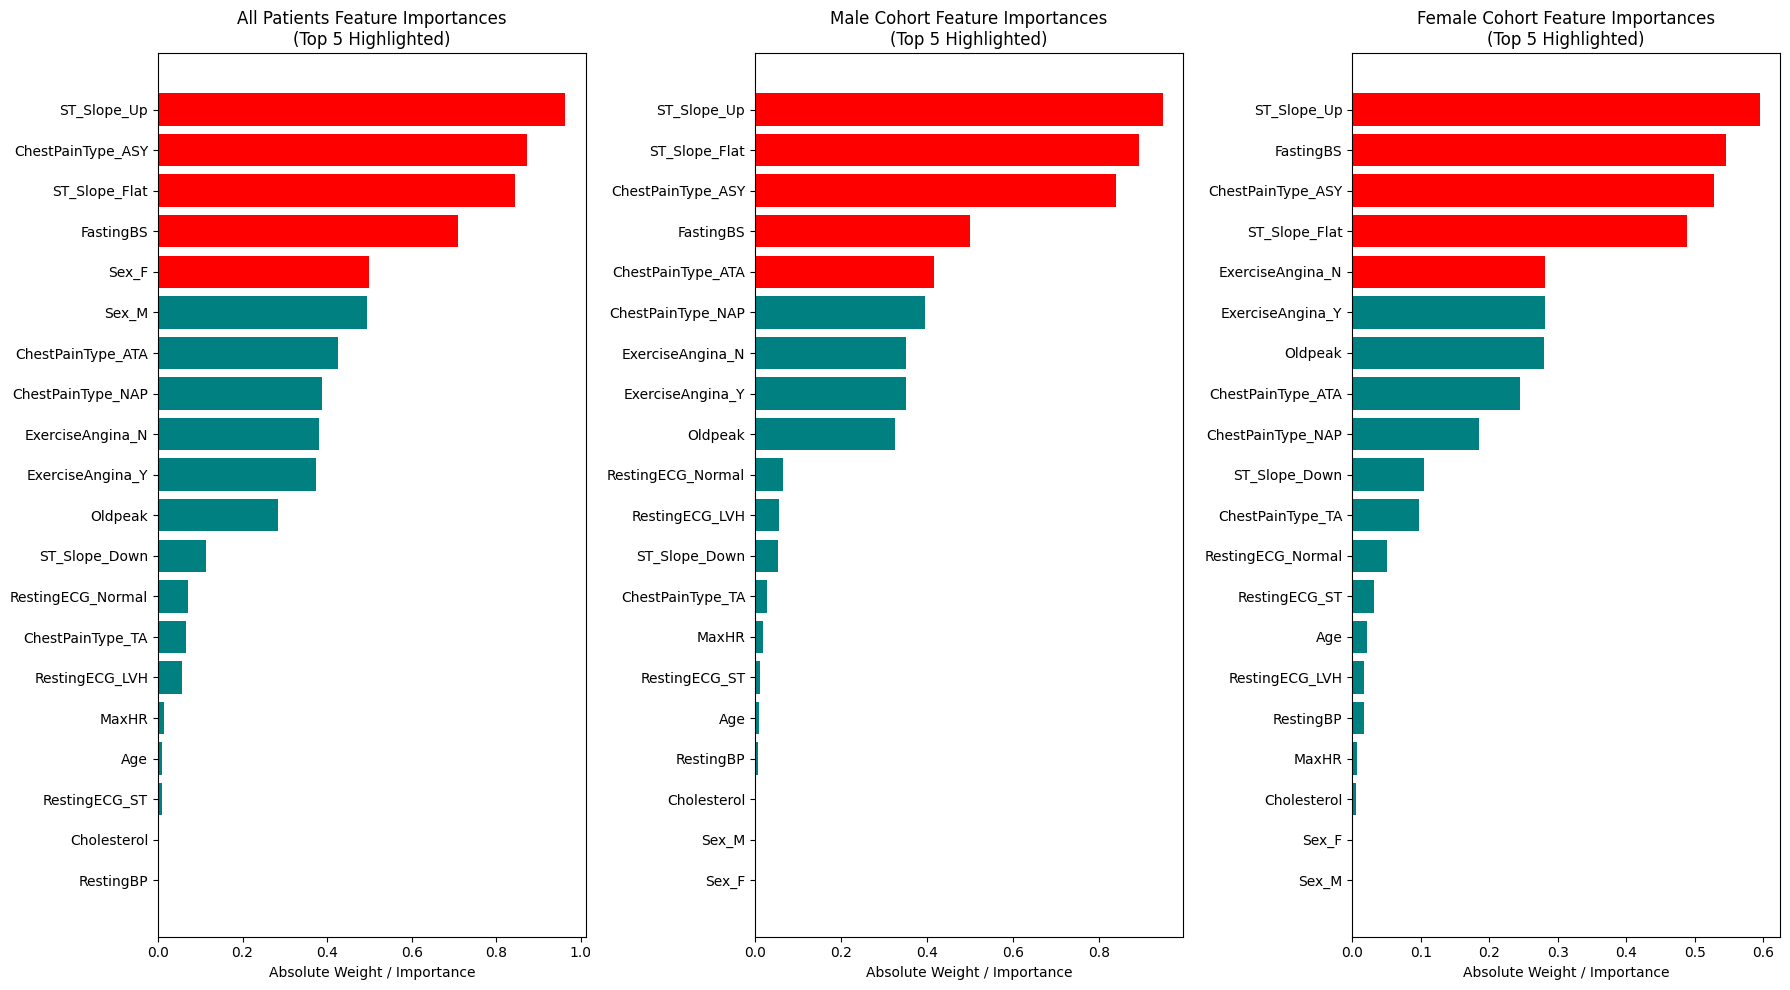

In [180]:

model_runs = [
    ('All Patients', best_rf_model, X_train_encoded.columns),
    ('Male Cohort', best_male_model, X_train_male.columns),
    ('Female Cohort', best_female_model, X_train_female.columns),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

for idx, (cohort_name, model, feature_cols) in enumerate(model_runs):
  # Get absolute weights for importance ranking
  if hasattr(model, 'coef_'):
    importances = np.abs(model.coef_[0])
  elif hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
  else:
    continue


  all_features_df = (
      pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
      .sort_values(by='Importance', ascending=False)
  )

  bar_colors = ['red' if i < 5 else 'teal' for i in range(len(all_features_df))]

  # Plot
  axes[idx].barh(range(len(all_features_df)), all_features_df['Importance'], color=bar_colors)
  axes[idx].set_yticks(range(len(all_features_df)))
  axes[idx].set_yticklabels(all_features_df['Feature'])
  axes[idx].invert_yaxis()
  
  # Updated title
  axes[idx].set_title(f'{cohort_name} Feature Importances\n(Top 5 Highlighted)')
  axes[idx].set_xlabel('Absolute Weight / Importance')

plt.tight_layout()
plt.show()

In [181]:


y_prob_all = best_rf_model.predict_proba(X_test_encoded)[:, 1]
y_pred_all = (y_prob_all >= clinical_threshold).astype(int)

error_df = X_test.copy()
error_df['True_Disease'] = y_test
error_df['Pred_Prob'] = y_prob_all
error_df['Predicted'] = y_pred_all

false_negatives = error_df[(error_df['True_Disease'] == 1) & (error_df['Predicted'] == 0)]
false_negatives = false_negatives.sort_values(by='Pred_Prob', ascending=False) 

false_positives = error_df[(error_df['True_Disease'] == 0) & (error_df['Predicted'] == 1)]
false_positives = false_positives.sort_values(by='Pred_Prob', ascending=False) 

# 5. Display the results
print(f"🚨 CRITICAL MISSES (False Negatives) - Total: {len(false_negatives)}")
print("These are patients WITH heart disease that the model sent home.")
display(false_negatives.style.background_gradient(subset=['Pred_Prob'], cmap='Reds'))

print(f"\n⚠️ FALSE ALARMS (False Positives) - Total: {len(false_positives)}")
print("These are healthy patients the model flagged for disease.")
display(false_positives.style.background_gradient(subset=['Pred_Prob'], cmap='Oranges'))

🚨 CRITICAL MISSES (False Negatives) - Total: 6
These are patients WITH heart disease that the model sent home.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,True_Disease,Pred_Prob,Predicted
1,49,F,NAP,160,180,0,Normal,156,N,1.000000,Flat,1,0.208467,0
763,58,M,NAP,132,224,0,LVH,173,N,3.200000,Up,1,0.193403,0
440,52,M,NAP,128,247,0,ST,180,N,3.000000,Up,1,0.163180,0
889,59,M,TA,134,204,0,Normal,162,N,0.800000,Up,1,0.142728,0
684,47,M,NAP,108,243,0,Normal,152,N,0.000000,Up,1,0.101365,0
759,54,M,ATA,192,283,0,LVH,195,N,0.000000,Up,1,0.063180,0



⚠️ FALSE ALARMS (False Positives) - Total: 18
These are healthy patients the model flagged for disease.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,True_Disease,Pred_Prob,Predicted
600,57,M,ASY,130,207,0,ST,96,Y,1.000000,Flat,0,0.942877,1
566,41,M,ASY,150,171,0,Normal,128,Y,1.500000,Flat,0,0.895616,1
314,53,M,ASY,80,237,0,Normal,141,Y,2.000000,Down,0,0.848259,1
434,63,M,ASY,126,242,0,ST,120,N,1.500000,Down,0,0.776384,1
783,45,F,ASY,138,236,0,LVH,152,Y,0.200000,Flat,0,0.680304,1
455,59,M,ASY,154,235,0,ST,131,Y,1.500000,Up,0,0.661197,1
798,42,F,ASY,102,265,0,LVH,122,N,0.600000,Flat,0,0.654878,1
626,53,M,ASY,142,226,0,LVH,111,Y,0.000000,Up,0,0.629072,1
605,51,F,ASY,114,258,1,LVH,96,N,1.000000,Up,0,0.521027,1
476,51,M,ASY,132,218,1,LVH,139,N,0.100000,Up,0,0.520834,1


In [182]:
from IPython.display import display

# Label every test-set row by its confusion-matrix outcome, so False
# Negatives/Positives can be compared AGAINST the correctly classified
# groups, not just viewed in isolation.
def confusion_label(row):
    if row['True_Disease'] == 1 and row['Predicted'] == 1:
        return 'True Positive'
    if row['True_Disease'] == 0 and row['Predicted'] == 0:
        return 'True Negative'
    if row['True_Disease'] == 1 and row['Predicted'] == 0:
        return 'False Negative'
    return 'False Positive'

error_df['Group'] = error_df.apply(confusion_label, axis=1)
group_order = ['True Positive', 'True Negative', 'False Negative', 'False Positive']

pd.set_option('display.max_columns', None)

numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

print("=== Numeric feature summary by outcome group ===")
display(
    error_df.groupby('Group')[numeric_cols]
    .agg(['count', 'median', 'std', 'min', 'max'])
    .reindex(group_order)
    .round(2)
)

print("\n=== Categorical feature breakdown by outcome group (row %) ===")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(
        pd.crosstab(error_df['Group'], error_df[col], normalize='index')
        .reindex(group_order)
        .round(2)
    )

=== Numeric feature summary by outcome group ===


Age                      RestingBP                          \
               count median   std min max     count median    std  min  max   
Group                                                                         
True Positive     96   56.0  8.15  34  75        96  133.0  18.06   95  185   
True Negative     64   46.0  9.05  28  71        64  130.0  14.15   98  160   
False Negative     6   53.0  4.79  47  59         6  133.0  29.46  108  192   
False Positive    18   51.5  7.78  40  65        18  130.0  19.44   80  155   

               Cholesterol                         MaxHR                     \
                     count median    std  min  max count median    std  min   
Group                                                                         
True Positive           96  241.0  54.78  110  518    96  125.5  17.97   82   
True Negative           64  229.0  46.72  132  342    64  156.0  21.67   98   
False Negative           6  233.5  36.00  180  283     6  167.5  16.23  152   
False Positive          18  234.0  26.60  171  265    18  131.5  26.72   80   

                    Oldpeak                         
                max   count median   std  min  max  
Group                                               
True Positive   170      96   1.50  1.17  0.0  6.2  
True Negative   194      64   0.00  0.42 -0.1  2.0  
False Negative  195       6   0.90  1.43  0.0  3.2  
False Positive  190      18   0.85  0.71  0.0  2.0


=== Categorical feature breakdown by outcome group (row %) ===

--- Sex ---


Sex,F,M
Group,,
True Positive,0.05,0.95
True Negative,0.45,0.55
False Negative,0.17,0.83
False Positive,0.17,0.83



--- ChestPainType ---


...

ExerciseAngina,N,Y
Group,,
True Positive,0.35,0.65
True Negative,0.97,0.03
False Negative,1.00,0.00
False Positive,0.61,0.39



--- ST_Slope ---


ST_Slope,Down,Flat,Up
Group,,,
True Positive,0.10,0.72,0.18
True Negative,0.05,0.12,0.83
False Negative,0.00,0.17,0.83
False Positive,0.17,0.44,0.39



--- FastingBS ---


FastingBS,0,1
Group,,
True Positive,0.61,0.39
True Negative,0.91,0.09
False Negative,1.00,0.00
False Positive,0.83,0.17


In [183]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone
import numpy as np

cv_raw_scores = {}  # stashed here so the chart cell below can use per-fold values

def run_cross_validation(fitted_model, X_tr, y_tr, X_te, y_te, label, cv_folds=5):
    # Combine train+test for this cohort so CV has the maximum data available
    # to estimate how STABLE the metric is -- this is purely a stability
    # check, not a re-selection of the final model.
    X_full = pd.concat([X_tr, X_te])
    y_full = pd.concat([y_tr, y_te])

    # Clone keeps the already-tuned hyperparameters (from GridSearchCV) but
    # strips fitted state, so each fold trains fresh -- no leakage from the
    # original train/test split into these folds.
    cv_estimator = clone(fitted_model)

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = cross_validate(
        cv_estimator, X_full, y_full, cv=cv,
        scoring=['recall', 'precision', 'f1', 'roc_auc', 'average_precision'],
        n_jobs=-1,
    )

    print(f"\n=== {label} ({cv_folds}-fold CV, n={len(y_full)}) ===")
    for metric in ['test_recall', 'test_f1', 'test_roc_auc', 'test_average_precision']:
        vals = scores[metric]
        print(f"{metric.replace('test_', ''):>18}: {vals.mean():.4f} ± {vals.std():.4f}  (folds: {np.round(vals, 3)})")

    cv_raw_scores[label] = scores

    return {
        "Group": label,
        "N": len(y_full),
        "CV Recall": f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "CV F1": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "CV ROC-AUC": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        "CV PR-AUC": f"{scores['test_average_precision'].mean():.4f} ± {scores['test_average_precision'].std():.4f}",
    }


cv_full = run_cross_validation(best_rf_model, X_train_encoded, y_train, X_test_encoded, y_test, "Full Dataset", cv_folds=5)
cv_male = run_cross_validation(best_male_model, X_train_male, y_train_male, X_test_male, y_test_male, "Male", cv_folds=5)
cv_female = run_cross_validation(best_female_model, X_train_female, y_train_female, X_test_female, y_test_female, "Female", cv_folds=5)

cv_comparison_df = pd.DataFrame([cv_full, cv_male, cv_female]).set_index("Group")
cv_comparison_df


=== Full Dataset (5-fold CV, n=918) ===
            recall: 0.8977 ± 0.0210  (folds: [0.873 0.912 0.882 0.891 0.931])
                f1: 0.8819 ± 0.0108  (folds: [0.873 0.894 0.87  0.878 0.895])
           roc_auc: 0.9230 ± 0.0077  (folds: [0.932 0.92  0.91  0.929 0.924])
 average_precision: 0.9256 ± 0.0128  (folds: [0.929 0.928 0.927 0.942 0.902])

=== Male (5-fold CV, n=725) ===
            recall: 0.9126 ± 0.0170  (folds: [0.902 0.902 0.946 0.912 0.901])
                f1: 0.8908 ± 0.0239  (folds: [0.883 0.874 0.916 0.86  0.921])
           roc_auc: 0.9096 ± 0.0221  (folds: [0.939 0.901 0.908 0.874 0.926])
 average_precision: 0.9317 ± 0.0274  (folds: [0.968 0.937 0.905 0.896 0.952])

=== Female (5-fold CV, n=193) ===
            recall: 0.7800 ± 0.0400  (folds: [0.8 0.8 0.7 0.8 0.8])
                f1: 0.6798 ± 0.0477  (folds: [0.696 0.727 0.609 0.727 0.64 ])
           roc_auc: 0.8865 ± 0.0419  (folds: [0.948 0.897 0.848 0.907 0.832])
 average_precision: 0.7650 ± 0.0780  (folds

,N,CV Recall,CV F1,CV ROC-AUC,CV PR-AUC
Group,,,,,
Full Dataset,918,0.8977 ± 0.0210,0.8819 ± 0.0108,0.9230 ± 0.0077,0.9256 ± 0.0128
Male,725,0.9126 ± 0.0170,0.8908 ± 0.0239,0.9096 ± 0.0221,0.9317 ± 0.0274
Female,193,0.7800 ± 0.0400,0.6798 ± 0.0477,0.8865 ± 0.0419,0.7650 ± 0.0780


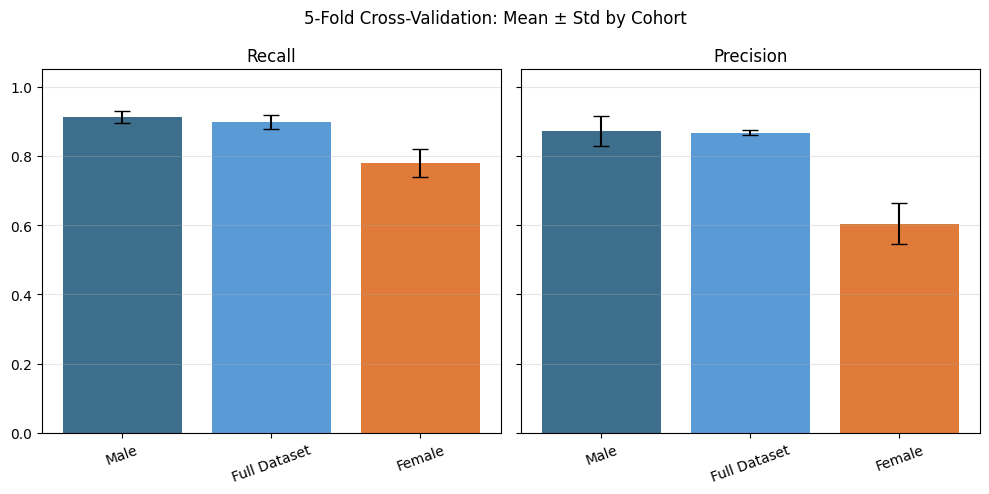

Saved to cv_results_by_cohort.png


In [191]:
metrics_to_plot = ['test_recall', 'test_precision']
metric_labels = ['Recall', 'Precision']
cohort_labels = ['Male', 'Full Dataset', 'Female']
cohort_colors = ['#3d6e8c', '#5b9bd5', '#e07b39']

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, metric, mlabel in zip(axes, metrics_to_plot, metric_labels):
    means = [cv_raw_scores[c][metric].mean() for c in cohort_labels]
    stds = [cv_raw_scores[c][metric].std() for c in cohort_labels]
    ax.bar(cohort_labels, means, yerr=stds, capsize=6, color=cohort_colors)
    ax.set_title(mlabel)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('5-Fold Cross-Validation: Mean \u00b1 Std by Cohort')
plt.tight_layout()
plt.savefig('cv_results_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to cv_results_by_cohort.png")

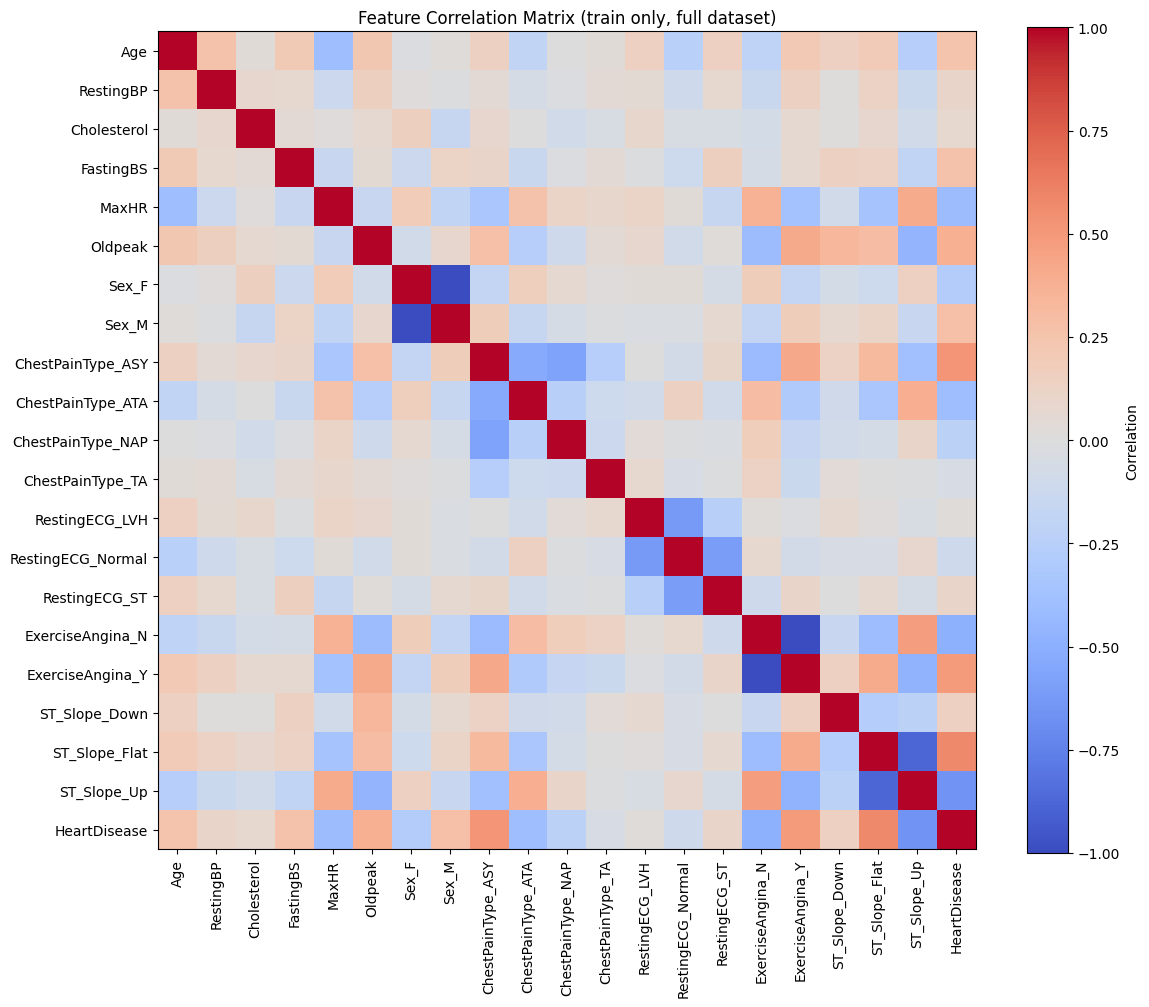

HeartDisease         1.000000
ST_Slope_Flat        0.570791
ChestPainType_ASY    0.518156
ExerciseAngina_Y     0.490873
Oldpeak              0.376603
Sex_M                0.280220
FastingBS            0.261391
Age                  0.244689
ST_Slope_Down        0.145547
RestingECG_ST        0.104397
RestingBP            0.102055
Cholesterol          0.072061
RestingECG_LVH       0.022259
ChestPainType_TA    -0.049802
RestingECG_Normal   -0.102490
ChestPainType_NAP   -0.226506
Sex_F               -0.280220
ChestPainType_ATA   -0.396565
MaxHR               -0.407227
ExerciseAngina_N    -0.490873
ST_Slope_Up         -0.649014
Name: HeartDisease, dtype: float64


In [185]:
train_full_corr = X_train_encoded.copy()
train_full_corr['HeartDisease'] = y_train
corr_matrix = train_full_corr.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Feature Correlation Matrix (train only, full dataset)')
plt.tight_layout()
plt.show()

print(corr_matrix['HeartDisease'].sort_values(ascending=False))

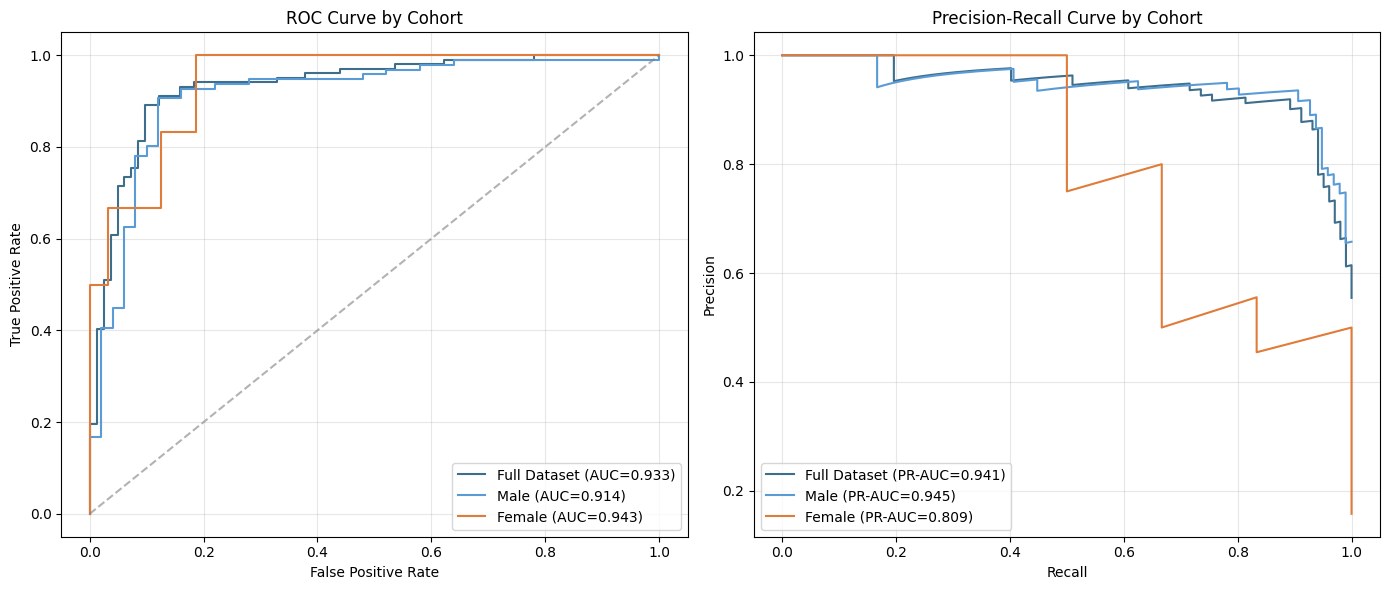

Saved to roc_pr_curves_by_cohort.png


In [195]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cohorts = [
    ('Full Dataset', y_test, y_prob_tuned, '#3d6e8c'),
    ('Male', y_test_male, y_prob_tuned_male, '#5b9bd5'),
    ('Female', y_test_female, y_prob_tuned_female, '#e07b39'),
]

for label, y_true, y_prob, color in cohorts:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC={auc_val:.3f})', color=color)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.6)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve by Cohort')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

for label, y_true, y_prob, color in cohorts:
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_val = average_precision_score(y_true, y_prob)
    axes[1].plot(recall, precision, label=f'{label} (PR-AUC={pr_auc_val:.3f})', color=color)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve by Cohort')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to roc_pr_curves_by_cohort.png")

### 3. Feature distributions by prediction outcome (False Negatives vs. everything else)

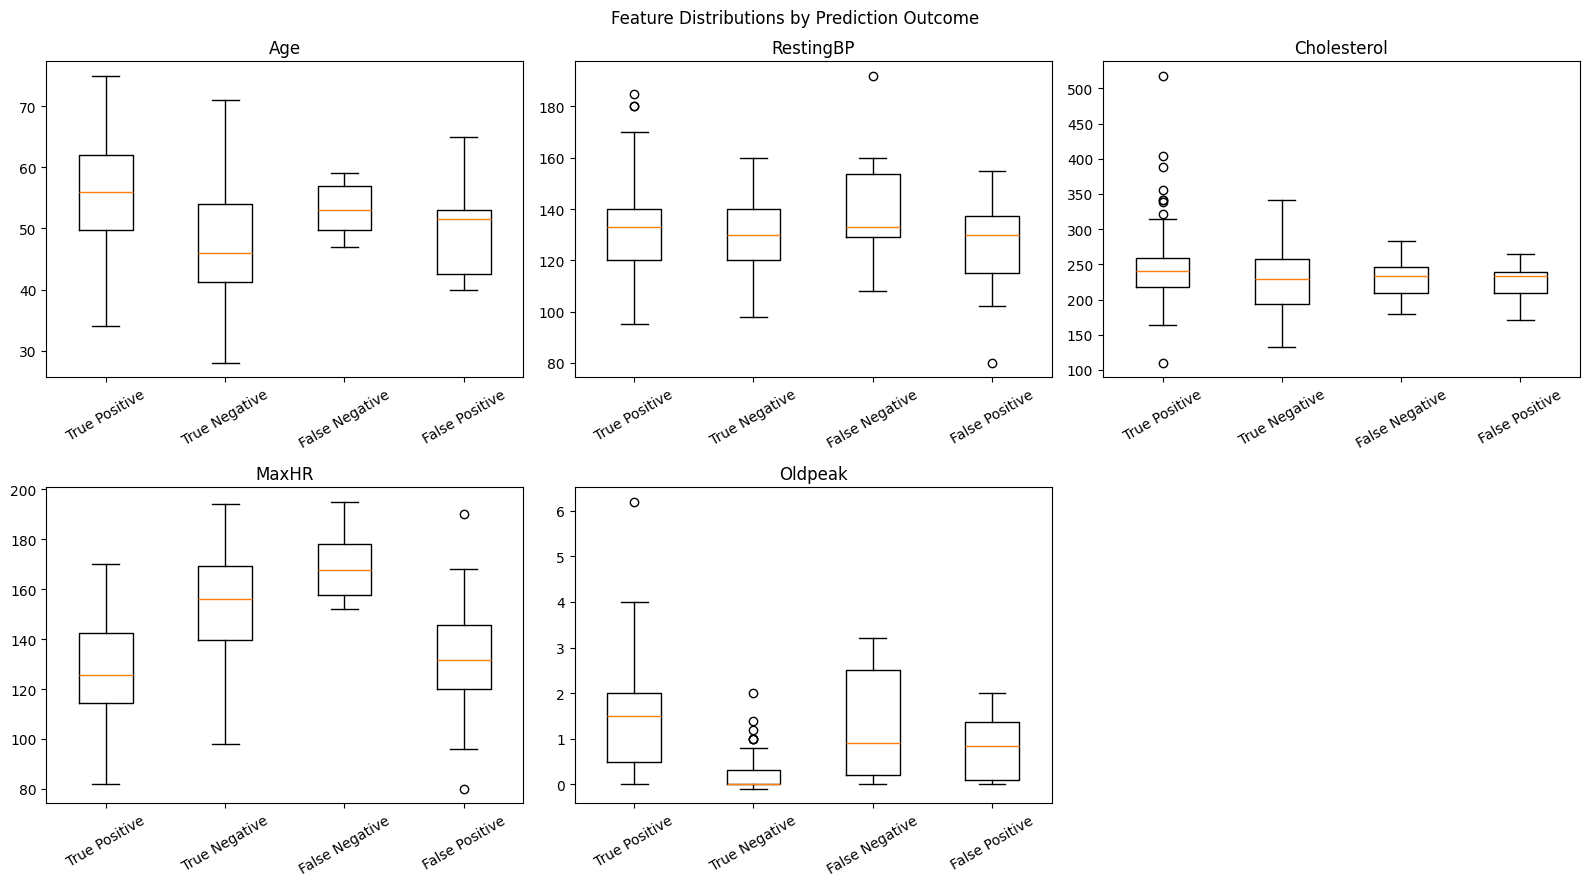

In [187]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_by_group = [error_df[error_df['Group'] == g][col] for g in group_order]
    axes[i].boxplot(data_by_group, tick_labels=group_order)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Feature Distributions by Prediction Outcome')
plt.tight_layout()
plt.show()

### 4. Heart disease prevalence by cohort

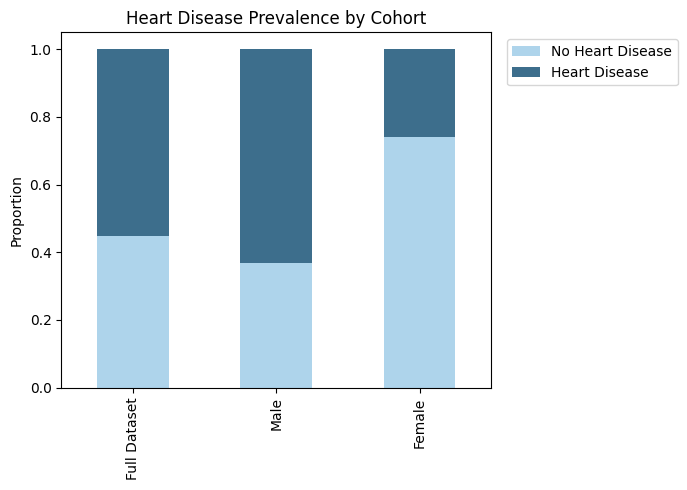

Saved to heart_disease_prevalence_by_cohort.png


In [188]:
fig, ax = plt.subplots(figsize=(7, 5))

rates = pd.DataFrame({
    'Full Dataset': df['HeartDisease'].value_counts(normalize=True).sort_index(),
    'Male': df[df['Sex'] == 'M']['HeartDisease'].value_counts(normalize=True).sort_index(),
    'Female': df[df['Sex'] == 'F']['HeartDisease'].value_counts(normalize=True).sort_index(),
}).T
rates.columns = ['No Heart Disease', 'Heart Disease']

rates.plot(kind='bar', stacked=True, ax=ax, color=['#aed4eb', '#3d6e8c'])
ax.set_ylabel('Proportion')
ax.set_title('Heart Disease Prevalence by Cohort')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('heart_disease_prevalence_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to heart_disease_prevalence_by_cohort.png")

In [196]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score


y_pred_combined_on_female = best_rf_model.predict(X_test_female)
y_prob_combined_on_female = best_rf_model.predict_proba(X_test_female)[:, 1]

print("=" * 60)
print("COMBINED MODEL, EVALUATED ON FEMALE PATIENTS ONLY")
print("=" * 60)
print(classification_report(y_test_female, y_pred_combined_on_female, target_names=['No Heart Disease (0)', 'Heart Disease (1)']))

roc_auc_combined_female = roc_auc_score(y_test_female, y_prob_combined_on_female)
pr_auc_combined_female = average_precision_score(y_test_female, y_prob_combined_on_female)
print(f"ROC-AUC: {roc_auc_combined_female:.4f}")
print(f"PR-AUC:  {pr_auc_combined_female:.4f}")

cm = confusion_matrix(y_test_female, y_pred_combined_on_female)
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (Correctly caught Heart Disease): {tp}")
print(f"False Negatives (Missed Heart Disease):           {fn}")
print(f"True Negatives  (Correctly identified Healthy):   {tn}")
print(f"False Positives (False Alarms):                   {fp}")

print("\n--- For comparison: FEMALE-ONLY model, same female test set ---")
print(classification_report(y_test_female, y_pred_tuned_female, target_names=['No Heart Disease (0)', 'Heart Disease (1)']))

COMBINED MODEL, EVALUATED ON FEMALE PATIENTS ONLY
                      precision    recall  f1-score   support

No Heart Disease (0)       0.94      0.91      0.92        32
   Heart Disease (1)       0.57      0.67      0.62         6

            accuracy                           0.87        38
           macro avg       0.75      0.79      0.77        38
        weighted avg       0.88      0.87      0.87        38

ROC-AUC: 0.9479
PR-AUC:  0.8062

True Positives  (Correctly caught Heart Disease): 4
False Negatives (Missed Heart Disease):           2
True Negatives  (Correctly identified Healthy):   29
False Positives (False Alarms):                   3

--- For comparison: FEMALE-ONLY model, same female test set ---
                      precision    recall  f1-score   support

No Heart Disease (0)       0.94      0.97      0.95        32
   Heart Disease (1)       0.80      0.67      0.73         6

            accuracy                           0.92        38
           macro a